In [ ]:
from google.colab import drive
!pip install -q open3d

import os, sys, math, random
import numpy as np
import pandas as pd
import open3d as o3d
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib import cm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.6 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/drive')

metadata_path = '/content/drive/MyDrive/ME 592/Project/Metadata.xlsx'
ply_folder    = '/content/drive/MyDrive/ME 592/Project/FielGrwon_ZeaMays_RawPCD_10k'
NUM_POINTS    = 10000 # tested with 1024 and 10000 samples points as input to models
BATCH_SIZE    = 32
EPOCHS        = 100
SEED          = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
metadata = pd.read_excel(metadata_path)
metadata = metadata[metadata['NumLeaves'] <= 40].reset_index(drop=True)
print(f"Metadata filtered: {len(metadata)} valid entries retained.")

Metadata filtered: 1044 valid entries retained.


Statistics of number of leaves

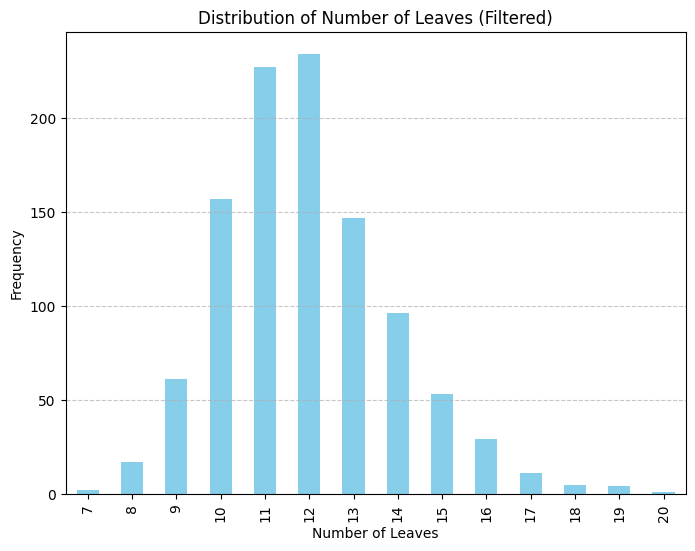

In [ ]:
# Plot the distribution of 'NumLeaves' as a bar graph
plt.figure(figsize=(8, 6))
metadata['NumLeaves'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of Number of Leaves (Filtered)')
plt.xlabel('Number of Leaves')
plt.ylabel('Frequency')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Plot plant

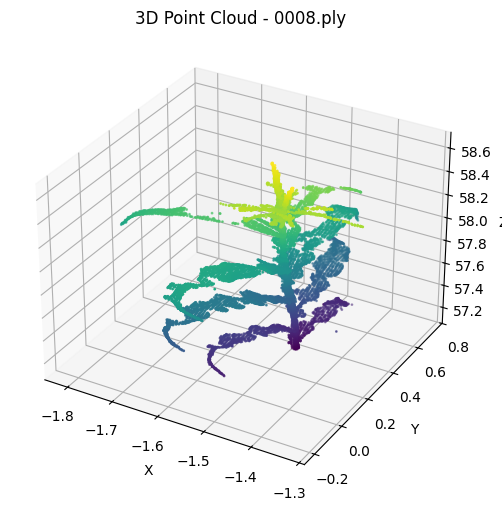

In [ ]:
# Pick an index you know exists (e.g., the 8th valid entry)
file_index = 8  # Change this as needed
file_name = f"{file_index:04d}.ply"
file_path = os.path.join(ply_folder, file_name)

# Read the point cloud
point_cloud = o3d.io.read_point_cloud(file_path)
points = np.asarray(point_cloud.points)

# Scatter plot using matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, c=points[:, 2], cmap='viridis')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"3D Point Cloud - {file_name}")
plt.show()


In [ ]:
all_paths, all_labels = [], []
for idx, row in metadata.iterrows():
    ply_path = os.path.join(ply_folder, f"{idx+1:04d}.ply")
    if os.path.exists(ply_path):
        all_paths.append(ply_path)
        all_labels.append(row['NumLeaves'])


In [ ]:
paths_tr, paths_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED)
paths_val, paths_te, y_val, y_te = train_test_split(
    paths_tmp, y_tmp, test_size=0.5, random_state=SEED)

In [ ]:
class MaizeCloud(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths  = paths
        self.labels = labels
        self.train  = train

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        pcd = o3d.io.read_point_cloud(self.paths[idx])
        pts = np.asarray(pcd.points, dtype=np.float32)
        pts -= pts.mean(0)
        pts /= (pts.std(0) + 1e-6)
        if self.train:
            theta = np.random.uniform(0, 2*np.pi)
            rot = np.array([[np.cos(theta), -np.sin(theta), 0],
                            [np.sin(theta),  np.cos(theta), 0],
                            [0,              0,             1]], dtype=np.float32)
            pts = pts @ rot.T
            pts += np.random.normal(scale=0.005, size=pts.shape).astype(np.float32)
        idxs = np.random.choice(pts.shape[0], NUM_POINTS, replace=pts.shape[0] < NUM_POINTS)
        pts = torch.from_numpy(pts[idxs])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return pts, label


In [ ]:
train_ds = MaizeCloud(paths_tr, y_tr, train=True)
val_ds   = MaizeCloud(paths_val, y_val, train=False)
test_ds  = MaizeCloud(paths_te, y_te, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Positional Encoding (like in NeRF)
class PositionalEncoding(nn.Module):
    def __init__(self, in_c=3, num_freqs=10, include_input=True):
        super().__init__()
        self.in_c = in_c
        self.num_freqs = num_freqs
        self.include_input = include_input

        freq_bands = 2.0 ** torch.linspace(0, num_freqs - 1, num_freqs)
        self.register_buffer('freq_bands', freq_bands)

    def forward(self, x):  # x: (B, N, C)
        B, N, C = x.shape
        freqs = self.freq_bands[None, None, :, None]      # (1, 1, F, 1)
        x_expanded = x[:, :, None, :]                     # (B, N, 1, C)
        freq = x_expanded * freqs                         # (B, N, F, C)

        sin = torch.sin(freq)
        cos = torch.cos(freq)
        encoded = torch.cat([sin, cos], dim=-1)           # (B, N, F, 2C)
        encoded = encoded.reshape(B, N, -1)               # (B, N, F*2*C)

        if self.include_input:
            encoded = torch.cat([x, encoded], dim=-1)     # (B, N, pe_dim)

        return encoded

# PointNet Block
class PointNetBlock(nn.Module):
    def __init__(self, in_c, mlp):
        super().__init__()
        layers = []
        c = in_c
        for k in mlp:
            layers += [nn.Conv1d(c, k, 1), nn.BatchNorm1d(k), nn.ReLU()]
            c = k
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):  # x: (B, C, N)
        return self.mlp(x)


# PointNet with Positional Encoding
class PointNetRegression(nn.Module):
    def __init__(self, in_c=3, mlp=[64, 128, 256], out_dim=1, num_freqs=5, include_input=True):
        super().__init__()
        self.posenc = PositionalEncoding(in_c, num_freqs, include_input)
        pe_dim = in_c * (2 * num_freqs) + (in_c if include_input else 0)
        self.feat = PointNetBlock(pe_dim, mlp)
        self.fc = nn.Linear(mlp[-1], out_dim)

    def forward(self, x):  # x: (B, N, 3)
        x = self.posenc(x)             # (B, N, pe_dim)
        x = x.transpose(2, 1)          # (B, pe_dim, N)
        x = self.feat(x)               # (B, mlp[-1], N)
        x = torch.max(x, 2)[0]         # (B, mlp[-1])
        return self.fc(x).squeeze(1)   # (B,)


In [ ]:
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
model    = PointNetRegression().to(device)
optimizer= optim.Adam(model.parameters(), lr=1e-3)
criterion= nn.MSELoss()

10000 Points

In [ ]:
train_losses, val_losses = [], []
best_val_loss = float('inf')  # Initialize best loss
best_model_path = 'best_model.pth'  # File to save best model

for epoch in range(1, EPOCHS+1):
    model.train(); running = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()
        loss = criterion(model(pts), lbl)
        loss.backward(); optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

    model.eval(); vloss = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            vloss += criterion(model(pts), lbl).item()
    val_losses.append(vloss / len(val_loader))

    # Save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch}/{EPOCHS} | Train {train_losses[-1]:.3f} | Val {val_losses[-1]:.3f}")


Epoch 1/100 | Train 47.758 | Val 28.997
Epoch 2/100 | Train 4.833 | Val 5.190
Epoch 3/100 | Train 3.726 | Val 4.963
Epoch 4/100 | Train 3.724 | Val 4.810
Epoch 5/100 | Train 3.578 | Val 4.760
Epoch 6/100 | Train 3.644 | Val 4.597
Epoch 7/100 | Train 3.368 | Val 4.658
Epoch 8/100 | Train 3.379 | Val 4.387
Epoch 9/100 | Train 3.391 | Val 4.529
Epoch 10/100 | Train 3.334 | Val 4.579
Epoch 11/100 | Train 3.445 | Val 4.367
Epoch 12/100 | Train 3.196 | Val 4.485
Epoch 13/100 | Train 3.561 | Val 4.354
Epoch 14/100 | Train 3.400 | Val 4.373
Epoch 15/100 | Train 3.232 | Val 4.427
Epoch 16/100 | Train 3.279 | Val 4.151
Epoch 17/100 | Train 3.225 | Val 4.029
Epoch 18/100 | Train 3.047 | Val 3.993
Epoch 19/100 | Train 3.180 | Val 4.869
Epoch 20/100 | Train 3.249 | Val 3.980
Epoch 21/100 | Train 3.162 | Val 4.143
Epoch 22/100 | Train 3.180 | Val 3.787
Epoch 23/100 | Train 3.040 | Val 3.889
Epoch 24/100 | Train 2.965 | Val 3.813
Epoch 25/100 | Train 2.975 | Val 3.789
Epoch 26/100 | Train 3.213 | Val

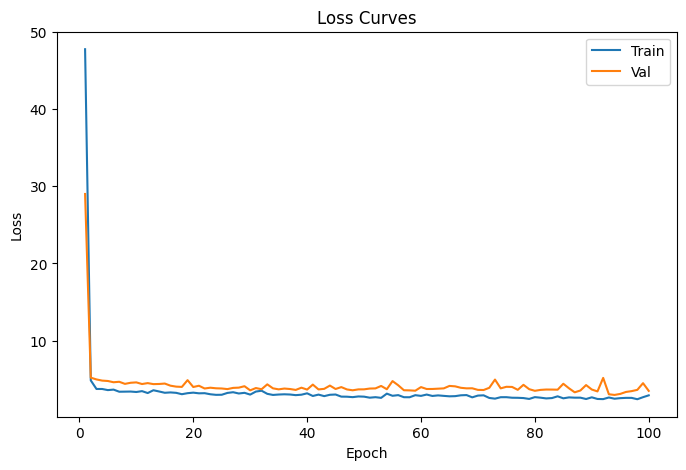

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train')
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.legend(); plt.show()

MSE : 3.4381
RMSE: 1.8542
MAE : 1.4381
R²  : -0.0426


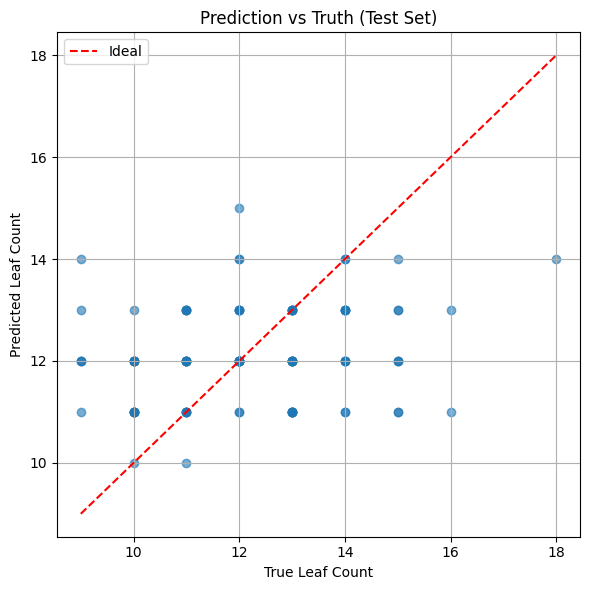

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load best model before testing
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_truth = [], []
with torch.no_grad():
    for pts, lbl in test_loader:
        pts = pts.to(device)
        preds = np.round(model(pts).cpu().numpy())
        all_preds.append(preds)
        all_truth.append(lbl.numpy())

# Flatten arrays
all_preds = np.concatenate(all_preds)
all_truth = np.concatenate(all_truth)

# --- Metrics ---
mse = mean_squared_error(all_truth, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_truth, all_preds)
r2 = r2_score(all_truth, all_preds)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# --- Scatter Plot ---
plt.figure(figsize=(6,6))
plt.scatter(all_truth, all_preds, alpha=0.6)
plt.plot([all_truth.min(), all_truth.max()], [all_truth.min(), all_truth.max()], 'r--', label='Ideal')
plt.xlabel('True Leaf Count')
plt.ylabel('Predicted Leaf Count')
plt.title('Prediction vs Truth (Test Set)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


1024 Points

In [ ]:
train_losses, val_losses = [], []
best_val_loss = float('inf')  # Initialize best loss
best_model_path = 'best_model.pth'  # File to save best model

for epoch in range(1, EPOCHS+1):
    model.train(); running = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()
        loss = criterion(model(pts), lbl)
        loss.backward(); optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

    model.eval(); vloss = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            vloss += criterion(model(pts), lbl).item()
    val_losses.append(vloss / len(val_loader))

    # Save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch}/{EPOCHS} | Train {train_losses[-1]:.3f} | Val {val_losses[-1]:.3f}")


Epoch 1/100 | Train 48.535 | Val 23.569
Epoch 2/100 | Train 4.732 | Val 4.989
Epoch 3/100 | Train 3.747 | Val 4.760
Epoch 4/100 | Train 3.827 | Val 4.816
Epoch 5/100 | Train 3.679 | Val 4.560
Epoch 6/100 | Train 3.666 | Val 4.640
Epoch 7/100 | Train 3.476 | Val 4.777
Epoch 8/100 | Train 3.406 | Val 4.519
Epoch 9/100 | Train 3.437 | Val 4.375
Epoch 10/100 | Train 3.366 | Val 4.424
Epoch 11/100 | Train 3.440 | Val 4.534
Epoch 12/100 | Train 3.300 | Val 4.423
Epoch 13/100 | Train 3.633 | Val 4.299
Epoch 14/100 | Train 3.408 | Val 4.325
Epoch 15/100 | Train 3.289 | Val 4.345
Epoch 16/100 | Train 3.301 | Val 4.022
Epoch 17/100 | Train 3.302 | Val 4.059
Epoch 18/100 | Train 3.149 | Val 4.113
Epoch 19/100 | Train 3.312 | Val 4.840
Epoch 20/100 | Train 3.395 | Val 4.220
Epoch 21/100 | Train 3.402 | Val 4.193
Epoch 22/100 | Train 3.282 | Val 3.932
Epoch 23/100 | Train 3.090 | Val 3.996
Epoch 24/100 | Train 3.072 | Val 3.987
Epoch 25/100 | Train 3.073 | Val 3.801
Epoch 26/100 | Train 3.218 | Val

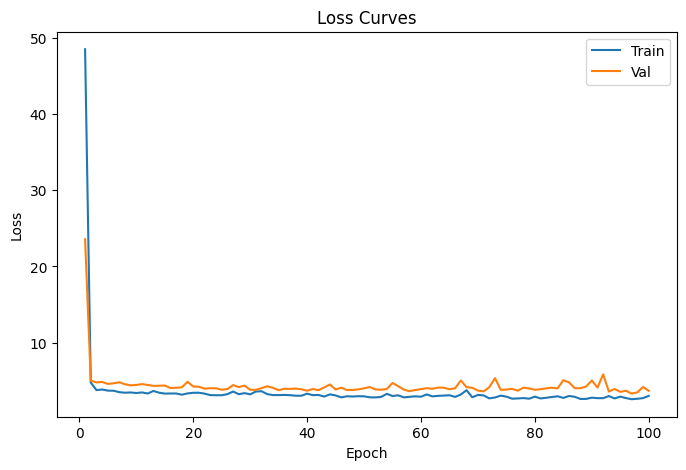

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train')
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves')
plt.legend(); plt.show()

MSE : 3.0381
RMSE: 1.7430
MAE : 1.3429
R²  : 0.0787


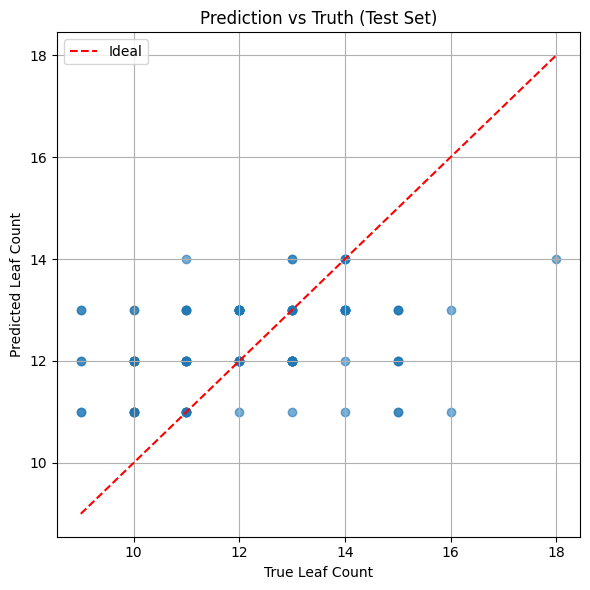

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load best model before testing
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_truth = [], []
with torch.no_grad():
    for pts, lbl in test_loader:
        pts = pts.to(device)
        preds = np.round(model(pts).cpu().numpy())
        all_preds.append(preds)
        all_truth.append(lbl.numpy())

# Flatten arrays
all_preds = np.concatenate(all_preds)
all_truth = np.concatenate(all_truth)

# --- Metrics ---
mse = mean_squared_error(all_truth, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_truth, all_preds)
r2 = r2_score(all_truth, all_preds)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# --- Scatter Plot ---
plt.figure(figsize=(6,6))
plt.scatter(all_truth, all_preds, alpha=0.6)
plt.plot([all_truth.min(), all_truth.max()], [all_truth.min(), all_truth.max()], 'r--', label='Ideal')
plt.xlabel('True Leaf Count')
plt.ylabel('Predicted Leaf Count')
plt.title('Prediction vs Truth (Test Set)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
